# Chapter 7 — Coordination: Two Groups
**Modeling Social Behavior** | Smaldino

---

## 📚 What This Model Adds

The previous two models had **one population**. This model splits agents into **two groups (A and B)** with their own internal norm dynamics. The key new question is:

> Can a prosocial norm that is already established in one group **spread into a second group** that currently lacks it — even if Norm 1 is rare in Group B?

This is the core insight from Boyd & Richerson (2002): **group structure can help prosocial norms spread** that would fail in a single unstructured population. The mechanism is **cross-group observation**. Agents occasionally look at what members of the other group are doing and, if they see higher payoffs, copy them.

---

## 🧩 The Setup

- There are two groups: **Group A** and **Group B**, each with $N/2$ agents.
- Each group starts with a **different initial frequency** of Norm 1:
  - Group A: `init_norm1_A` (set high, e.g. 0.8 — Norm 1 already established)
  - Group B: `init_norm1_B` (set low, e.g. 0.2 — Norm 1 struggling)
- Payoffs are calculated **within each group separately** (same asymmetric formula as before).
- Imitation happens **mostly within-group**, but with a small probability `prob_outgroup` agents look across the boundary.

---

## 🎯 The Central Mechanism: Cross-Group Observation

Each tick, when an agent chooses who to observe:
- With probability `1 - prob_outgroup` → pick someone from **own group**
- With probability `prob_outgroup` → pick someone from **the other group**

When a Group B agent (Norm 2, low payoff) observes a Group A agent (Norm 1, high payoff due to coordination), they may copy Norm 1 — even though Norm 1 is currently rare in Group B and would normally be penalized there.

**This creates a pipeline**: Group A acts as a living demonstration that Norm 1 can succeed. Group B agents who observe Group A see high payoffs and import the norm — even across the rarity-cost barrier.

---

## 🧮 Payoff Structure (Same as Asymmetric Model, But Per Group)

For each group $k$ with Norm 1 frequency $p_k$:

$$\pi_1^{(k)} = p_k(1 + b_p + b_c) + (1 - p_k)(1 - c_r)$$
$$\pi_2^{(k)} = p_k(1 + b_p) + (1 - p_k)$$

The tipping point within each group is still:
$$p^* = \frac{c_r}{c_r + b_c}$$

**The key tension**: Group B's Norm 1 frequency starts *below* $p^*$. Left alone, Norm 1 would die out. But cross-group observation from a high-$p_A$ Group A can rescue it — if the prosocial benefit $b_p$ is large enough to make Group A agents visibly better off.

---

## 💡 Why Does the Prosocial Benefit Matter Now?

Recall that in the single-population asymmetric model, $b_p$ **cancelled out of p*** and didn't affect the tipping point. Here it matters differently:

- Group A, with high $p_A$, earns a high payoff from both $b_c$ AND $b_p$.
- When Group B agents observe Group A agents, they see payoffs that include $b_p$.
- Higher $b_p$ → bigger payoff gap between Group A (Norm 1) and Group B (Norm 2) → stronger pull to copy Norm 1.

So $b_p$ is the engine of **inter-group norm diffusion**, even though it doesn't affect within-group dynamics.

---

## 🔢 Variable Reference

| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents (split equally between groups) |
| `init_norm1_A` | Global (param) | Initial Norm 1 frequency in Group A |
| `init_norm1_B` | Global (param) | Initial Norm 1 frequency in Group B |
| `norm1_prosocial_benefit` | Global (param) | $b_p$: spillover benefit even for Norm 2 partners |
| `norm1_coord_benefit` | Global (param) | $b_c$: extra bonus when two Norm 1 agents meet |
| `norm1_rarity_cost` | Global (param) | $c_r$: cost Norm 1 pays when paired with Norm 2 |
| `prob_outgroup` | Global (param) | Probability of observing someone from the other group |
| `agent.norm` | Agent | Integer: 1 or 2 |
| `agent.group` | Agent | Integer: 0 = Group A, 1 = Group B |
| `agent.payoff` | Agent | Float: current expected payoff |
| `p_A`, `p_B` | Local | Norm 1 frequency within each group this tick |
| `history_A`, `history_B` | Global | Per-group norm frequency over time |

---

## 📦 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import random

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## 🤖 Agent Class

Now agents have a **group identity** in addition to a norm and a payoff.

In [2]:
class Agent:
    """
    Represents one individual in the two-group coordination model.

    Agent-level attributes:
    -----------------------
    norm   : int   — which norm the agent holds (1 or 2)
    group  : int   — which group the agent belongs to (0 = Group A, 1 = Group B)
    payoff : float — the agent's expected payoff this tick (set by calculate_payoffs)
    """

    def __init__(self, norm, group):
        self.norm   = norm    # int: 1 or 2
        self.group  = group   # int: 0 (Group A) or 1 (Group B)
        self.payoff = 0.0     # float: updated each tick

---
## ⚙️ Model Functions

In [3]:
def setup(N, init_norm1_A, init_norm1_B):
    """
    Create the two-group population with different starting norm frequencies.

    N agents total: N//2 assigned to Group A, N//2 to Group B.
    Group A starts with init_norm1_A frequency of Norm 1.
    Group B starts with init_norm1_B frequency of Norm 1.

    Parameters (global):
    --------------------
    N            : int   — total number of agents
    init_norm1_A : float — initial Norm 1 frequency in Group A (0 to 1)
    init_norm1_B : float — initial Norm 1 frequency in Group B (0 to 1)

    Returns:
    --------
    agents : list of Agent
    """
    agents = []
    n_per_group = N // 2  # local: agents per group (assumes N is even)

    # Create Group A agents
    for _ in range(n_per_group):
        norm = 1 if random.random() < init_norm1_A else 2
        agents.append(Agent(norm=norm, group=0))

    # Create Group B agents
    for _ in range(n_per_group):
        norm = 1 if random.random() < init_norm1_B else 2
        agents.append(Agent(norm=norm, group=1))

    return agents


def calculate_payoffs(agents, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost):
    """
    Calculate payoffs for every agent based on WITHIN-GROUP norm frequencies.

    This is the critical design choice: payoffs depend only on what is happening
    *inside* your own group, not globally. A Norm 1 agent in Group B gets a low
    payoff because Norm 1 is rare in Group B — regardless of how common it is in A.

    Payoff formulas (same as asymmetric model, applied per group):
        π₁ = p_k*(1 + bp + bc) + (1-p_k)*(1 - cr)
        π₂ = p_k*(1 + bp)      + (1-p_k)*1
    where p_k = Norm 1 frequency within group k.

    Parameters (all global-level):
    ------------------------------
    agents                  : list of Agent
    norm1_prosocial_benefit : float — bp
    norm1_coord_benefit     : float — bc
    norm1_rarity_cost       : float — cr

    Modifies agents in place.
    """

    # Loop over each group separately
    for g in [0, 1]:  # g = group ID

        # Local: all agents in this group
        group_agents = [a for a in agents if a.group == g]
        n_group      = len(group_agents)  # local: size of this group

        # Local: Norm 1 frequency WITHIN this group
        p_k = sum(1 for a in group_agents if a.norm == 1) / n_group

        # Local: payoffs for each norm in this group
        norm1_payoff = (p_k * (1 + norm1_prosocial_benefit + norm1_coord_benefit)
                       + (1 - p_k) * (1 - norm1_rarity_cost))
        norm2_payoff = (p_k * (1 + norm1_prosocial_benefit)
                       + (1 - p_k) * 1)

        # Assign payoffs to each agent in this group
        for agent in group_agents:
            agent.payoff = norm1_payoff if agent.norm == 1 else norm2_payoff


def fermi(payoff_other, payoff_self):
    """
    Logistic (Fermi) function: probability of copying the other agent's norm.

    P(copy) = 1 / (1 + exp(-(payoff_other - payoff_self)))

    Same as in both previous models.
    """
    return 1.0 / (1.0 + np.exp(-(payoff_other - payoff_self)))


def evolve(agents, prob_outgroup):
    """
    One full round of success-biased imitation with cross-group observation.

    For each agent:
    1. Decide whether to observe within-group or across groups.
       - With prob (1 - prob_outgroup): observe own group (ingroup)
       - With prob prob_outgroup:       observe the other group (outgroup)
    2. Pick a random agent from the chosen group.
    3. Apply the Fermi rule: copy their norm with probability proportional
       to the payoff advantage of the observed agent.

    Parameters:
    -----------
    agents        : list of Agent — the full population
    prob_outgroup : float — probability of looking at the other group (global param)

    Modifies agents in place.
    """

    shuffled = agents[:]           # local: shuffled copy of agent list
    random.shuffle(shuffled)

    # Pre-separate agents by group to avoid filtering inside the loop (efficiency)
    group_agents = {
        0: [a for a in agents if a.group == 0],  # local: Group A
        1: [a for a in agents if a.group == 1],  # local: Group B
    }

    for agent in shuffled:
        my_group    = agent.group      # local: this agent's group
        other_group = 1 - my_group     # local: the other group (0→1 or 1→0)

        # Decide which pool to sample from
        if random.random() < prob_outgroup:
            # Look across the group boundary
            observe_group = other_group
        else:
            # Look within own group
            observe_group = my_group

        # local: pick one random agent from the chosen group
        model = random.choice(group_agents[observe_group])

        # Apply Fermi rule: copy with probability based on payoff difference
        prob_copy = fermi(model.payoff, agent.payoff)  # local

        if random.random() < prob_copy:
            agent.norm = model.norm


def p_star(norm1_rarity_cost, norm1_coord_benefit):
    """
    Analytical tipping point: p* = cr / (cr + bc).
    Same formula as in the asymmetric single-group model.
    """
    return norm1_rarity_cost / (norm1_rarity_cost + norm1_coord_benefit)


def run(N, init_norm1_A, init_norm1_B,
        norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost,
        prob_outgroup, max_ticks=2000):
    """
    Run the two-group coordination simulation.

    Tracks Norm 1 frequency separately for each group over time.

    Global parameters:
    ------------------
    N                       : int   — total agents (N//2 per group)
    init_norm1_A            : float — initial Norm 1 freq in Group A
    init_norm1_B            : float — initial Norm 1 freq in Group B
    norm1_prosocial_benefit : float — bp
    norm1_coord_benefit     : float — bc
    norm1_rarity_cost       : float — cr
    prob_outgroup           : float — probability of cross-group observation
    max_ticks               : int   — simulation length cap

    Returns:
    --------
    history_A : list of float — Norm 1 frequency in Group A each tick
    history_B : list of float — Norm 1 frequency in Group B each tick
    """

    agents    = setup(N, init_norm1_A, init_norm1_B)
    n_per_grp = N // 2  # local: agents per group

    history_A = []  # global tracking list: Group A
    history_B = []  # global tracking list: Group B

    for tick in range(max_ticks):

        # Count Norm 1 holders in each group this tick
        n1_A = sum(1 for a in agents if a.group == 0 and a.norm == 1)  # local
        n1_B = sum(1 for a in agents if a.group == 1 and a.norm == 1)  # local

        history_A.append(n1_A / n_per_grp)
        history_B.append(n1_B / n_per_grp)

        # Stop if Norm 1 has fixed everywhere (taken over both groups)
        if (n1_A + n1_B) == N:
            break

        calculate_payoffs(agents, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost)
        evolve(agents, prob_outgroup)

    return history_A, history_B

---
## 🔬 Experiment 0: Baseline — What Happens Without Cross-Group Observation?

Before turning on cross-group observation, let's confirm that **without it**, each group evolves independently according to its own starting frequency and p*.

- Group A: starts at 0.8, well above p* → Norm 1 should win.
- Group B: starts at 0.2, well below p* → Norm 1 should go extinct.

Setting `prob_outgroup = 0` makes the two groups completely isolated.

p* = 0.333
Group A starts at 0.8 → above p*
Group B starts at 0.22 → below p*
With no cross-group observation, expect: Group A → Norm 1 wins, Group B → Norm 1 lost


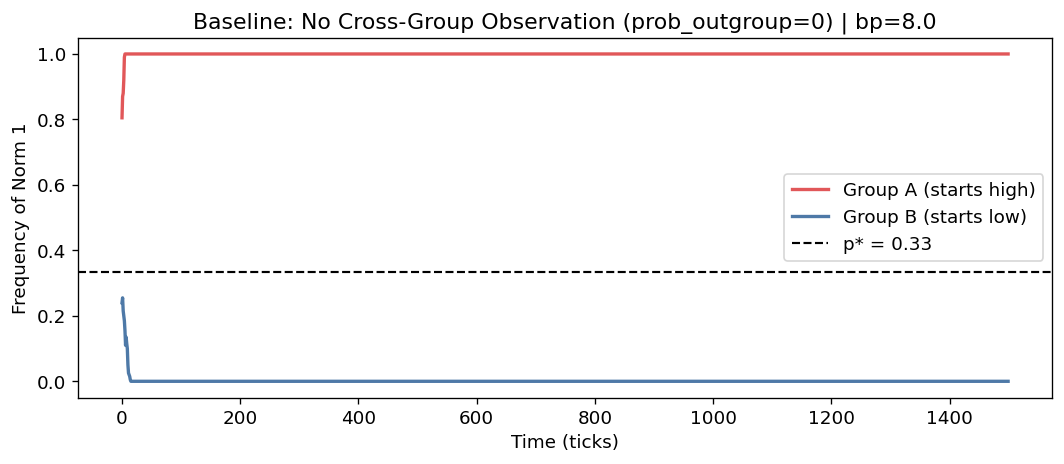


Final freq Norm 1 — Group A: 1.000 | Group B: 0.000


In [4]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 400    # total agents (200 per group)
init_norm1_A            = 0.80   # Group A: Norm 1 well established
init_norm1_B            = 0.22   # Group B: Norm 1 struggling (below p*)
norm1_prosocial_benefit = 8.0    # bp: large, as in the NetLogo defaults
norm1_coord_benefit     = 1.0    # bc
norm1_rarity_cost       = 0.5    # cr
prob_outgroup           = 0.0    # NO cross-group observation — fully isolated
max_ticks               = 1500
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)
print(f"p* = {pstar:.3f}")
print(f"Group A starts at {init_norm1_A} → {'above' if init_norm1_A > pstar else 'below'} p*")
print(f"Group B starts at {init_norm1_B} → {'above' if init_norm1_B > pstar else 'below'} p*")
print(f"With no cross-group observation, expect: Group A → Norm 1 wins, Group B → Norm 1 lost")

random.seed(7)
hA, hB = run(N, init_norm1_A, init_norm1_B,
             norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost,
             prob_outgroup, max_ticks)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(hA, color='#e15759', linewidth=2, label='Group A (starts high)')
ax.plot(hB, color='#4e79a7', linewidth=2, label='Group B (starts low)')
ax.axhline(pstar, color='black', linestyle='--', linewidth=1.3,
           label=f'p* = {pstar:.2f}')

ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1')
ax.set_title(f'Baseline: No Cross-Group Observation (prob_outgroup=0) | bp={norm1_prosocial_benefit}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal freq Norm 1 — Group A: {hA[-1]:.3f} | Group B: {hB[-1]:.3f}")

---
## 🔬 Experiment 1: Turning On Cross-Group Observation

Now we introduce a small probability of observing the other group.

**What should happen:** Group B agents, when they occasionally observe Group A, see Norm 1 holders with high payoffs (because Norm 1 is dominant in Group A and yields large $b_p + b_c$ bonuses). This makes copying Norm 1 attractive even though Norm 1 is rare in Group B.

If enough Group B agents copy Norm 1 this way, Group B's Norm 1 frequency can climb above $p^*$, at which point within-group dynamics take over and Norm 1 spreads on its own.

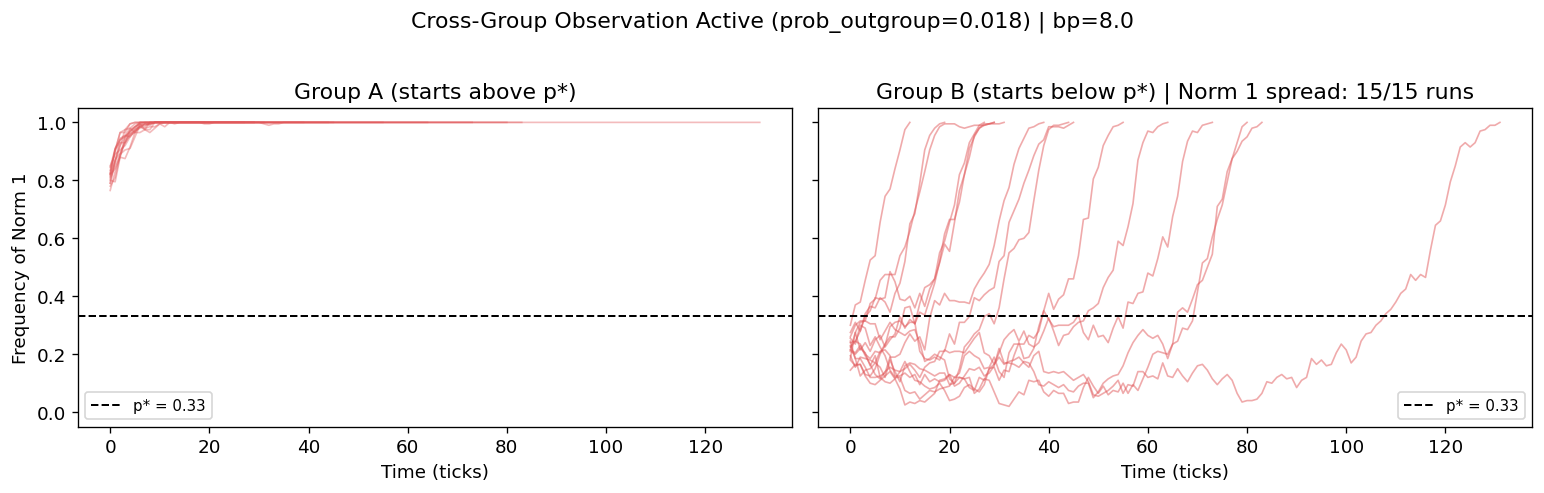

Norm 1 spread to Group B in 15/15 runs (100%)


In [5]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 400
init_norm1_A            = 0.80
init_norm1_B            = 0.22
norm1_prosocial_benefit = 8.0    # bp: high — makes Group A agents visibly better off
norm1_coord_benefit     = 1.0    # bc
norm1_rarity_cost       = 0.5    # cr → p* = 0.5/(0.5+1) = 0.333
prob_outgroup           = 0.018  # small but nonzero cross-group observation rate
max_ticks               = 1500
n_runs                  = 15     # multiple runs to show stochastic variation
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

wins_B = 0   # local: how many runs did Norm 1 win in Group B?

for _ in range(n_runs):
    hA, hB = run(N, init_norm1_A, init_norm1_B,
                 norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost,
                 prob_outgroup, max_ticks)
    won_B = hB[-1] > 0.9  # local: did Norm 1 take over Group B?
    if won_B: wins_B += 1

    color = '#e15759' if won_B else '#aec7e8'  # red = spread, light blue = didn't spread
    axes[0].plot(hA, color='#e15759', alpha=0.4, linewidth=1)  # Group A always wins
    axes[1].plot(hB, color=color, alpha=0.5, linewidth=1)

for ax, title in zip(axes, ['Group A', 'Group B']):
    ax.axhline(pstar, color='black', linestyle='--', linewidth=1.2, label=f'p* = {pstar:.2f}')
    ax.set_xlabel('Time (ticks)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Frequency of Norm 1')
axes[0].set_title('Group A (starts above p*)')
axes[1].set_title(f'Group B (starts below p*) | Norm 1 spread: {wins_B}/{n_runs} runs')

fig.suptitle(f'Cross-Group Observation Active (prob_outgroup={prob_outgroup}) | bp={norm1_prosocial_benefit}',
             y=1.02)
plt.tight_layout()
plt.show()

legend_elements = [
    Patch(facecolor='#e15759', alpha=0.7, label='Norm 1 spread to Group B'),
    Patch(facecolor='#aec7e8', alpha=0.7, label='Norm 1 failed in Group B'),
]
print(f"Norm 1 spread to Group B in {wins_B}/{n_runs} runs ({100*wins_B/n_runs:.0f}%)")

---
## 🔬 Experiment 2: The Role of the Prosocial Benefit (bp)

This is the key experiment from the book (mirroring the NetLogo batch `experiment2`).

We sweep `norm1_prosocial_benefit` from 0 to 8 and measure how often Norm 1 spreads to Group B.

**Expected result:** Low $b_p$ → Group A doesn't look much better than Group B → little incentive to copy → Norm 1 stays low in Group B. High $b_p$ → large visible payoff gap between the groups → strong pull to copy Norm 1 → Norm 1 spreads.

In [6]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                   = 400
init_norm1_A        = 0.80
init_norm1_B        = 0.22
norm1_coord_benefit = 1.0
norm1_rarity_cost   = 0.5
prob_outgroup       = 0.018
max_ticks           = 1500
n_reps              = 60     # repetitions per bp value

# Sweep prosocial benefit
bp_values = np.arange(0.0, 8.5, 0.5)  # 0, 0.5, 1.0, ..., 8.0
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)
spread_probs = []  # global result: fraction of runs where Norm 1 spread to Group B

for bp in bp_values:
    spread_count = 0  # local counter
    for _ in range(n_reps):
        _, hB = run(N, init_norm1_A, init_norm1_B,
                    bp, norm1_coord_benefit, norm1_rarity_cost,
                    prob_outgroup, max_ticks)
        if hB[-1] > 0.9:   # Norm 1 effectively took over Group B
            spread_count += 1
    spread_probs.append(spread_count / n_reps)
    print(f"  bp={bp:.1f} | Norm 1 spread to Group B: {spread_count}/{n_reps}", flush=True)

print("\nDone!")

  bp=0.0 | Norm 1 spread to Group B: 60/60
  bp=0.5 | Norm 1 spread to Group B: 60/60
  bp=1.0 | Norm 1 spread to Group B: 60/60
  bp=1.5 | Norm 1 spread to Group B: 60/60
  bp=2.0 | Norm 1 spread to Group B: 60/60
  bp=2.5 | Norm 1 spread to Group B: 60/60
  bp=3.0 | Norm 1 spread to Group B: 60/60
  bp=3.5 | Norm 1 spread to Group B: 60/60
  bp=4.0 | Norm 1 spread to Group B: 60/60
  bp=4.5 | Norm 1 spread to Group B: 60/60
  bp=5.0 | Norm 1 spread to Group B: 60/60
  bp=5.5 | Norm 1 spread to Group B: 60/60
  bp=6.0 | Norm 1 spread to Group B: 60/60
  bp=6.5 | Norm 1 spread to Group B: 60/60
  bp=7.0 | Norm 1 spread to Group B: 60/60
  bp=7.5 | Norm 1 spread to Group B: 60/60
  bp=8.0 | Norm 1 spread to Group B: 60/60

Done!


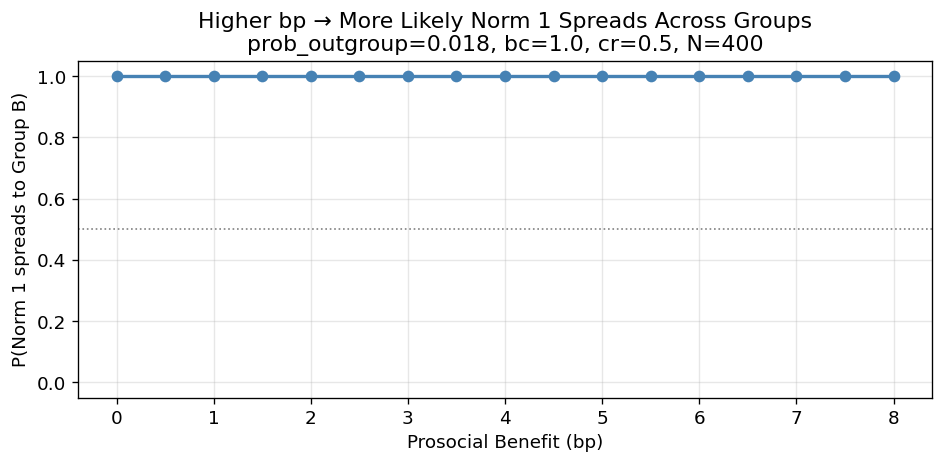

Key insight: bp doesn't help within-group dynamics (doesn't shift p*),
but it makes Group A visibly more successful, driving cross-group norm diffusion.


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(bp_values, spread_probs, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

ax.set_xlabel('Prosocial Benefit (bp)')
ax.set_ylabel('P(Norm 1 spreads to Group B)')
ax.set_title(
    f'Higher bp → More Likely Norm 1 Spreads Across Groups\n'
    f'prob_outgroup={prob_outgroup}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}, N={N}'
)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: bp doesn't help within-group dynamics (doesn't shift p*),")
print("but it makes Group A visibly more successful, driving cross-group norm diffusion.")

---
## 🔬 Experiment 3: The Role of Cross-Group Contact (prob_outgroup)

More cross-group contact gives Group B agents more chances to observe the successful Group A Norm 1 holders. But contact alone isn't enough. The payoff gap must be large enough to motivate copying.

Here we sweep `prob_outgroup` at a fixed (moderately high) `bp` to show the effect of contact rate.

In [8]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 400
init_norm1_A            = 0.80
init_norm1_B            = 0.22
norm1_prosocial_benefit = 4.0    # fixed at a moderate level
norm1_coord_benefit     = 1.0
norm1_rarity_cost       = 0.5
max_ticks               = 1500
n_reps                  = 60

# Sweep cross-group observation probability
outgroup_values = np.arange(0.000, 0.051, 0.005)  # 0%, 0.5%, ..., 5%
# ───────────────────────────────────────────────────────────────────────────────

spread_probs_contact = []  # global result list

for prob_og in outgroup_values:
    spread_count = 0  # local
    for _ in range(n_reps):
        _, hB = run(N, init_norm1_A, init_norm1_B,
                    norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost,
                    prob_og, max_ticks)
        if hB[-1] > 0.9:
            spread_count += 1
    spread_probs_contact.append(spread_count / n_reps)
    print(f"  prob_outgroup={prob_og:.3f} | Spread: {spread_count}/{n_reps}", flush=True)

print("\nDone!")

  prob_outgroup=0.000 | Spread: 3/60
  prob_outgroup=0.005 | Spread: 7/60
  prob_outgroup=0.010 | Spread: 47/60
  prob_outgroup=0.015 | Spread: 60/60
  prob_outgroup=0.020 | Spread: 60/60
  prob_outgroup=0.025 | Spread: 60/60
  prob_outgroup=0.030 | Spread: 60/60
  prob_outgroup=0.035 | Spread: 60/60
  prob_outgroup=0.040 | Spread: 60/60
  prob_outgroup=0.045 | Spread: 60/60
  prob_outgroup=0.050 | Spread: 60/60

Done!


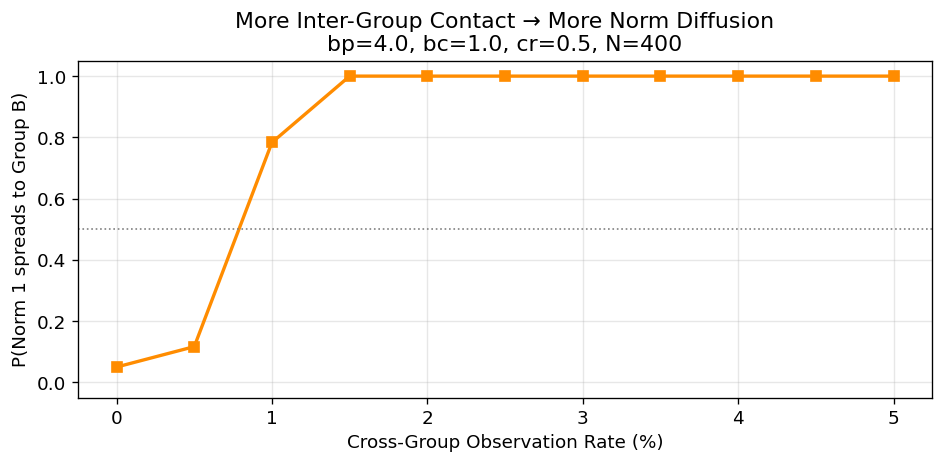

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(outgroup_values * 100, spread_probs_contact, 's-',
        color='darkorange', linewidth=2, markersize=6)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

ax.set_xlabel('Cross-Group Observation Rate (%)')
ax.set_ylabel('P(Norm 1 spreads to Group B)')
ax.set_title(
    f'More Inter-Group Contact → More Norm Diffusion\n'
    f'bp={norm1_prosocial_benefit}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}, N={N}'
)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 4: Joint Effect of bp and prob_outgroup — Heatmap

Both `bp` (the visibility of success) and `prob_outgroup` (the contact rate) drive norm diffusion. Let's map them jointly to show the region where cross-group norm spread reliably occurs.

In [10]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                   = 400
init_norm1_A        = 0.80
init_norm1_B        = 0.22
norm1_coord_benefit = 1.0
norm1_rarity_cost   = 0.5
max_ticks           = 1200
n_reps              = 30    # lower reps for speed (heatmap has many cells)

bp_grid      = np.arange(0.0, 8.5, 1.0)         # prosocial benefit axis
outgrp_grid  = np.arange(0.000, 0.031, 0.005)   # contact rate axis
# ───────────────────────────────────────────────────────────────────────────────

# Build the heatmap matrix
heatmap = np.zeros((len(outgrp_grid), len(bp_grid)))  # rows = contact rate, cols = bp

for i, prob_og in enumerate(outgrp_grid):
    for j, bp in enumerate(bp_grid):
        spread_count = 0  # local
        for _ in range(n_reps):
            _, hB = run(N, init_norm1_A, init_norm1_B,
                        bp, norm1_coord_benefit, norm1_rarity_cost,
                        prob_og, max_ticks)
            if hB[-1] > 0.9:
                spread_count += 1
        heatmap[i, j] = spread_count / n_reps
    print(f"  prob_outgroup={prob_og:.3f} done", flush=True)

print("\nDone!")

  prob_outgroup=0.000 done
  prob_outgroup=0.005 done
  prob_outgroup=0.010 done
  prob_outgroup=0.015 done
  prob_outgroup=0.020 done
  prob_outgroup=0.025 done
  prob_outgroup=0.030 done

Done!


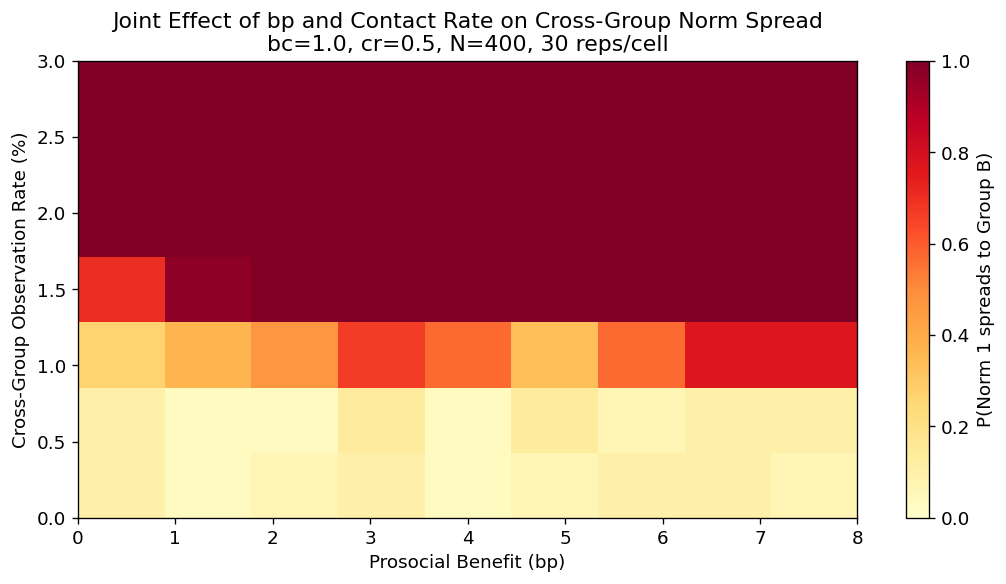

Dark red = Norm 1 reliably spreads; Yellow = rarely spreads
Both high bp AND some contact are needed for reliable cross-group diffusion.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(heatmap, origin='lower', aspect='auto',
               extent=[bp_grid[0], bp_grid[-1],
                       outgrp_grid[0]*100, outgrp_grid[-1]*100],
               cmap='YlOrRd', vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label='P(Norm 1 spreads to Group B)')
ax.set_xlabel('Prosocial Benefit (bp)')
ax.set_ylabel('Cross-Group Observation Rate (%)')
ax.set_title(
    f'Joint Effect of bp and Contact Rate on Cross-Group Norm Spread\n'
    f'bc={norm1_coord_benefit}, cr={norm1_rarity_cost}, N={N}, {n_reps} reps/cell'
)
plt.tight_layout()
plt.show()

print("Dark red = Norm 1 reliably spreads; Yellow = rarely spreads")
print("Both high bp AND some contact are needed for reliable cross-group diffusion.")

---
## 🔬 Experiment 5: Visualizing the Tipping Dynamic in Group B

When cross-group spread works, it follows a characteristic two-phase pattern in Group B:

1. **Import phase**: Cross-group observation slowly drips Norm 1 into Group B. The frequency drifts upward but unevenly — sometimes it gets knocked back.
2. **Tipping phase**: Once Group B's Norm 1 frequency crosses p*, within-group dynamics take over and the norm rapidly spreads to fixation.

Let's plot many Group B trajectories to see this two-phase pattern clearly.

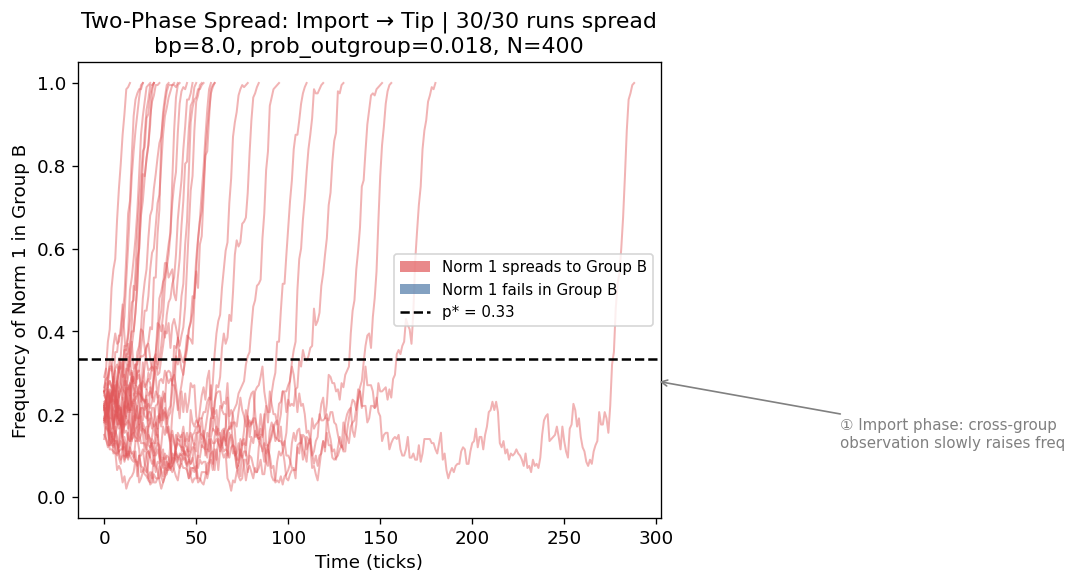

In [12]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 400
init_norm1_A            = 0.80
init_norm1_B            = 0.22
norm1_prosocial_benefit = 8.0
norm1_coord_benefit     = 1.0
norm1_rarity_cost       = 0.5
prob_outgroup           = 0.018
max_ticks               = 1500
n_runs                  = 30
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

fig, ax = plt.subplots(figsize=(10, 5))

spread_count = 0  # local counter
for _ in range(n_runs):
    _, hB = run(N, init_norm1_A, init_norm1_B,
                norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost,
                prob_outgroup, max_ticks)
    spread = hB[-1] > 0.9
    if spread: spread_count += 1
    color = '#e15759' if spread else '#4e79a7'
    ax.plot(hB, color=color, alpha=0.45, linewidth=1.2)

ax.axhline(pstar, color='black', linestyle='--', linewidth=1.5,
           label=f'p* = {pstar:.2f} (within-group tipping point)')

# Annotate the two phases
ax.annotate('① Import phase: cross-group\nobservation slowly raises freq',
            xy=(300, 0.28), fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'),
            xytext=(400, 0.12))
ax.annotate('② Tipping: within-group selection\ntakes over above p*',
            xy=(900, 0.65), fontsize=9, color='#e15759',
            arrowprops=dict(arrowstyle='->', color='#e15759'),
            xytext=(700, 0.80))

legend_elements = [
    Patch(facecolor='#e15759', alpha=0.7, label='Norm 1 spreads to Group B'),
    Patch(facecolor='#4e79a7', alpha=0.7, label='Norm 1 fails in Group B'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black',
          linestyle='--', label=f'p* = {pstar:.2f}')], fontsize=9)

ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1 in Group B')
ax.set_title(
    f'Two-Phase Spread: Import → Tip | {spread_count}/{n_runs} runs spread\n'
    f'bp={norm1_prosocial_benefit}, prob_outgroup={prob_outgroup}, N={N}'
)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

---

## 📝 Conceptual Summary

| Concept | What It Means In This Model |
|---|---|
| **Two-group structure** | Payoffs are calculated within each group separately — norm frequency in Group A doesn't directly help Norm 1 holders in Group B |
| **Cross-group observation** | Agents occasionally look across the group boundary and may copy based on payoff differences |
| **Import phase** | Cross-group observation slowly seeds Norm 1 into Group B against the within-group selection pressure |
| **Tipping phase** | Once Group B's Norm 1 frequency crosses p*, within-group dynamics amplify it to fixation |
| **Role of bp** | Doesn't shift p* within groups, but makes Group A visibly richer — fueling cross-group imitation |
| **Role of prob_outgroup** | More inter-group contact = more seeding = faster path to tipping |
| **Group structure solves the bootstrapping problem** | Norm 1 can't spontaneously emerge in Group B because it starts below p*, but it can be *imported* from Group A |
| **Boyd & Richerson insight** | Group structure allows prosocial norms to spread that would fail in a single unstructured population |

---

## 🔗 How the Three Models Build on Each Other

| Model | Key Question | What's New |
|---|---|---|
| **Simple** | Which norm wins when they're equal? | Baseline coordination; stochastic fixation; p* = 0.5 |
| **Asymmetric** | What if one norm is prosocially better but costly when rare? | Tipping point p* = cr/(cr+bc); path dependence; lock-in |
| **Two Groups** | Can a better norm spread from a group where it's established to one where it isn't? | Group identity; within-group payoffs; cross-group observation; two-phase spread |